I begin by downloading dependencies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Takehome assignment. Exercise 1: Logins. 

I'm going to begin by loading in the dataframes and inspecting the data for issues.

In [2]:
df  = pd.read_json(r'C:\Users\ryan1\Desktop\ultimate_challenge\logins.json')
df.head(10)

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21
5,1970-01-01 20:21:41
6,1970-01-01 20:12:16
7,1970-01-01 20:35:47
8,1970-01-01 20:35:38
9,1970-01-01 20:47:52


In [3]:
df.shape

(93142, 1)

In [4]:
df.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


In [5]:
df.dtypes

login_time    datetime64[ns]
dtype: object

In [6]:
(df.login_time.max() - df.login_time.min())/np.timedelta64(15, 'm')

9787.024444444445

In [7]:
print("Duplicate rows:", df.duplicated().sum())
print("Exact duplicate timestamps:", df['login_time'].duplicated().sum())
print()
print("Null values:")
print(df.isnull().sum())
print()
print("Monotonic increasing:", df['login_time'].is_monotonic_increasing)
print("Min timestamp:", df['login_time'].min())
print("Max timestamp:", df['login_time'].max())
print("Total span (days):", (df['login_time'].max() - df['login_time'].min()).days)


full_range = pd.date_range(df['login_time'].min().normalize(), df['login_time'].max().normalize(), freq='D')
present_dates = pd.to_datetime(df['login_time'].dt.date.unique())
missing_dates = full_range.difference(present_dates)
print("\nCalendar dates with zero logins:", len(missing_dates))
if len(missing_dates):
    print(missing_dates)

Duplicate rows: 877
Exact duplicate timestamps: 877

Null values:
login_time    0
dtype: int64

Monotonic increasing: False
Min timestamp: 1970-01-01 20:12:16
Max timestamp: 1970-04-13 18:57:38
Total span (days): 101

Calendar dates with zero logins: 0


In [8]:
df['date'] = df.login_time.dt.date
df['day'] = df.login_time.dt.day
df['time'] = df.login_time.dt.time
df['interval'] = df.login_time.dt.floor('15min').dt.strftime('%H:%M')
df['login_azt'] = df.login_time.dt.tz_localize('UTC').dt.tz_convert('America/Phoenix')
df['azt_interval'] = df.login_time.dt.floor('15min').dt.strftime('%H:%M')
df.groupby('azt_interval').size()

azt_interval
00:00    1439
00:15    1547
00:30    1525
00:45    1482
01:00    1549
         ... 
22:45    1637
23:00    1573
23:15    1552
23:30    1456
23:45    1477
Length: 96, dtype: int64

In [9]:
# Fixed: derive azt_interval from the timezone-converted column, not the raw one
df['azt_interval'] = df['login_azt'].dt.floor('15min').dt.strftime('%H:%M')
df['weekday'] = df['login_azt'].dt.day_name()   # also recompute weekday in local time, not raw

df.groupby('azt_interval').size()

azt_interval
00:00    219
00:15    229
00:30    192
00:45    175
01:00    191
        ... 
22:45    457
23:00    369
23:15    320
23:30    235
23:45    214
Length: 96, dtype: int64

Visualizing counts by date to find missing values ... 

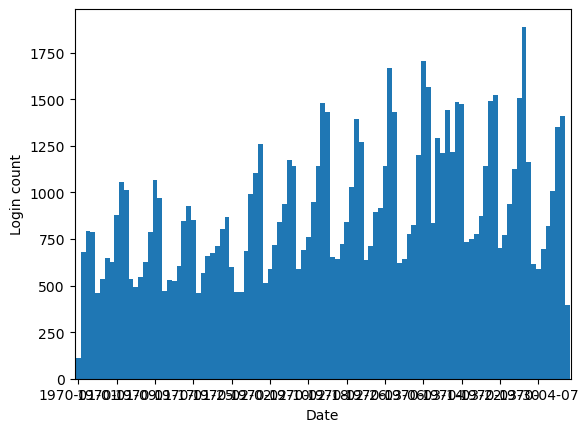

In [10]:
counts = df['date'].value_counts().sort_index()
ax = counts.plot(kind='bar', width=1.0)
ax.set_xticks(range(0, len(counts), 8))  # every 8th = every 2 hours
ax.set_xticklabels(counts.index[::8], rotation=0)
plt.xlabel('Date')
plt.ylabel('Login count')
plt.show()

Doesn't look like there are missing dates. Date visualization shows cyclical behavior. Let's break it down by day. 

In [11]:
df['weekday'] = df.login_time.dt.day_name()
df.groupby(['weekday', 'azt_interval']).size()

weekday    azt_interval
Friday     00:00           26
           00:15           27
           00:30           33
           00:45           19
           01:00           29
                           ..
Wednesday  22:45           15
           23:00           12
           23:15           15
           23:30           10
           23:45           11
Length: 672, dtype: int64

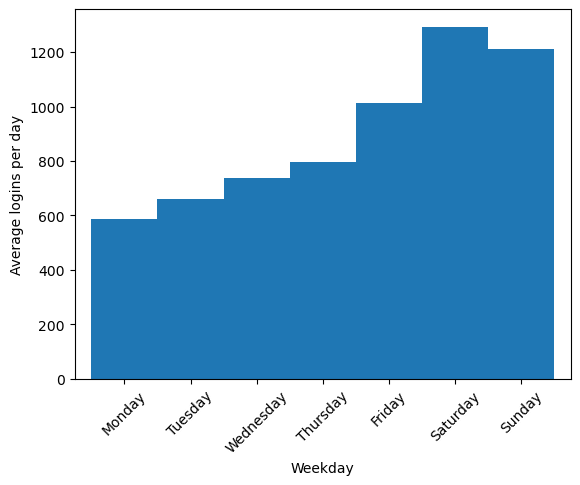

In [ ]:
per_day = df.groupby('date').size().rename('logins').reset_index()
per_day['date'] = pd.to_datetime(per_day['date'])
per_day['weekday'] = per_day['date'].dt.day_name()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg = per_day.groupby('weekday')['logins'].mean().reindex(order)

ax = avg.plot(kind='bar', width=1.0)
ax.set_xticklabels(avg.index, rotation=45)
plt.xlabel('Weekday')
plt.ylabel('Average logins per day')
plt.show()

Interesting. Activity seems to average highest on the weekends. This might be indicative of a consumer site. Maybe an enterainment page. The 1970 year raises a flag, this must not be a webpage (?) Unless that's one of the data issues that I was intended to flag. 

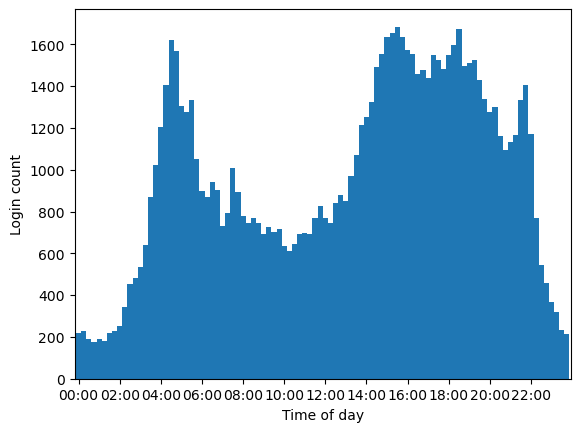

In [13]:
counts = df['azt_interval'].value_counts().sort_index()
ax = counts.plot(kind='bar', width=1.0)
ax.set_xticks(range(0, len(counts), 8))  # every 8th = every 2 hours
ax.set_xticklabels(counts.index[::8], rotation=0)
plt.xlabel('Time of day')
plt.ylabel('Login count')
plt.show()

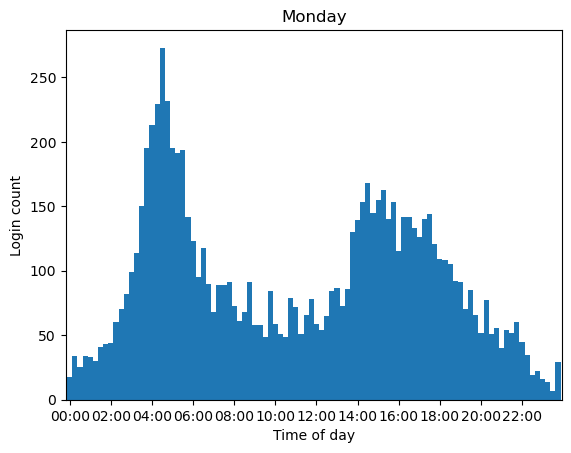

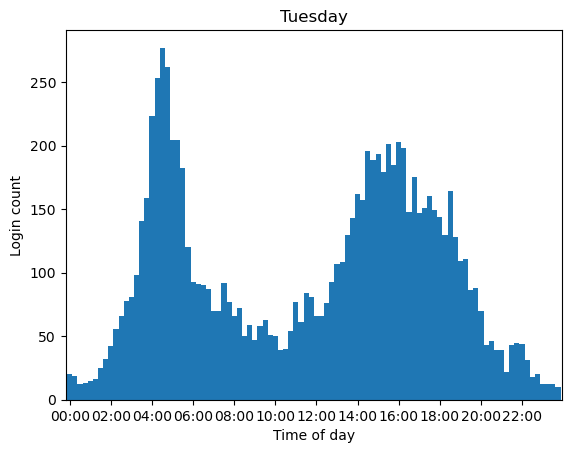

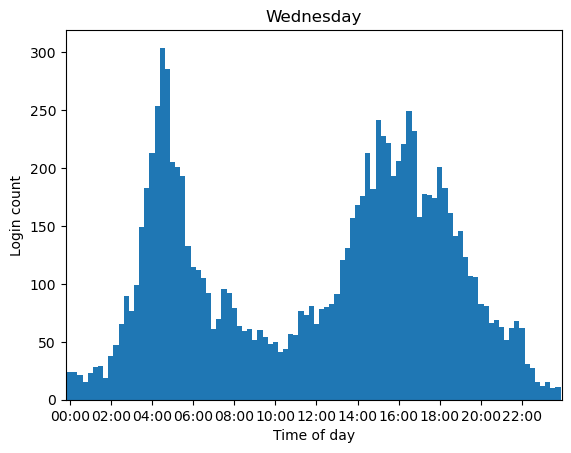

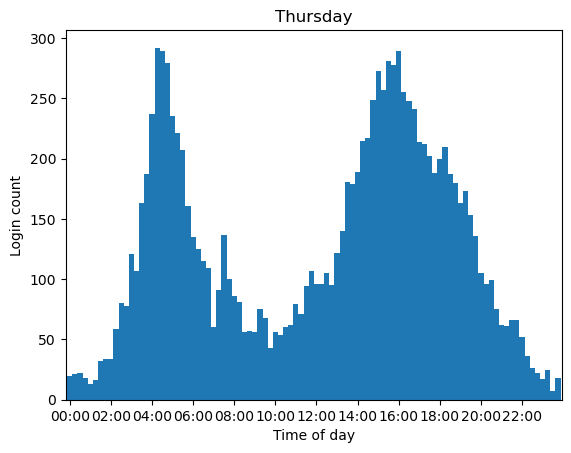

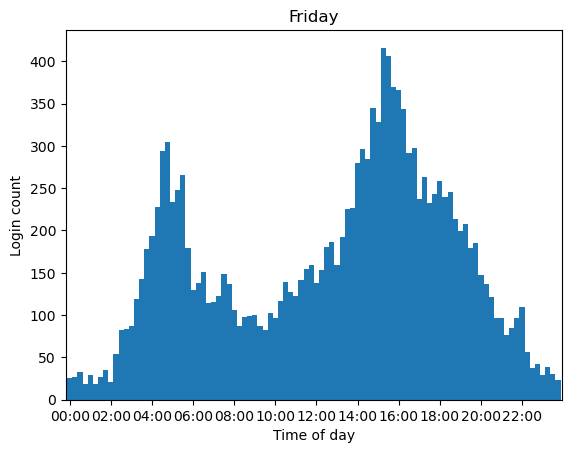

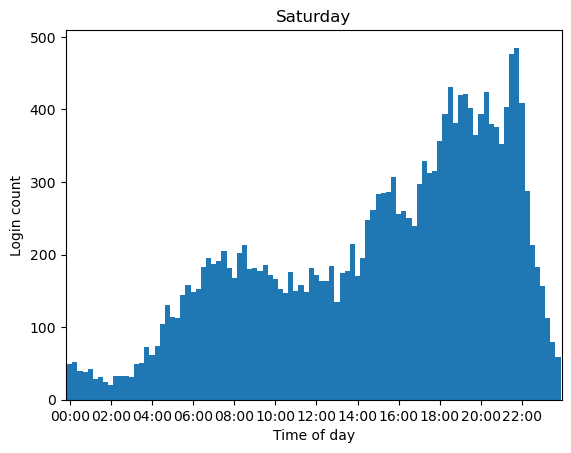

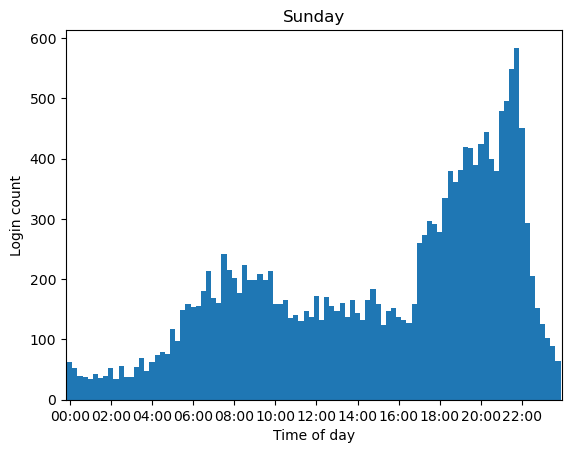

In [14]:
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for day in days_of_week:
    day_data = df[df['weekday'] == day]
    counts = day_data['azt_interval'].value_counts().sort_index()
    ax = counts.plot(kind='bar', width=1.0, title=day)
    ax.set_xticks(range(0, len(counts), 8))  # every 8th = every 2 hours
    ax.set_xticklabels(counts.index[::8], rotation=0)
    plt.xlabel('Time of day')
    plt.ylabel('Login count')
    plt.show()

Broken down by 15 min intervals the site shows a tri-peak distribution. Showing late night/early morning activity and mid afternooon activity. Interesteing this pattern seems to break on the weekends. With more late morning activity. Could this be a brunch property? 

count    9788.000000
mean        9.515938
std         8.328818
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        73.000000
Name: logins, dtype: float64


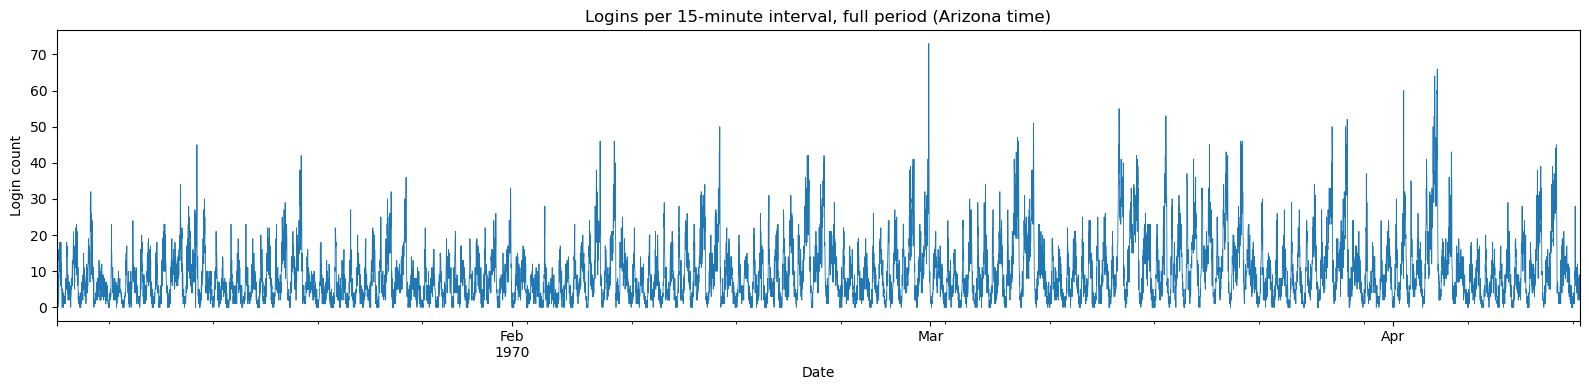

In [ ]:
ts = (
    df.set_index('login_azt')
      .resample('15min')
      .size()
      .rename('logins')
)

print(ts.describe())

fig, ax = plt.subplots(figsize=(16, 4))
ts.plot(ax=ax, linewidth=0.6)
ax.set_title('Logins per 15-minute interval, full period (Arizona time)')
ax.set_xlabel('Date')
ax.set_ylabel('Login count')
plt.tight_layout()
plt.show()

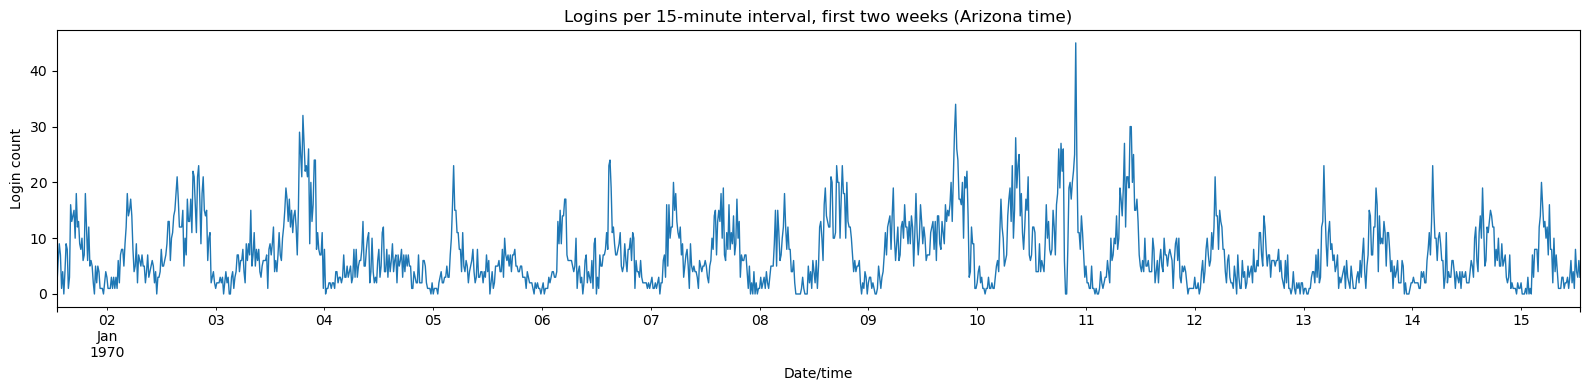

In [16]:
zoom = ts.loc[ts.index.min() : ts.index.min() + pd.Timedelta(days=14)]

fig, ax = plt.subplots(figsize=(16, 4))
zoom.plot(ax=ax, linewidth=1)
ax.set_title('Logins per 15-minute interval, first two weeks (Arizona time)')
ax.set_xlabel('Date/time')
ax.set_ylabel('Login count')
plt.tight_layout()
plt.show()

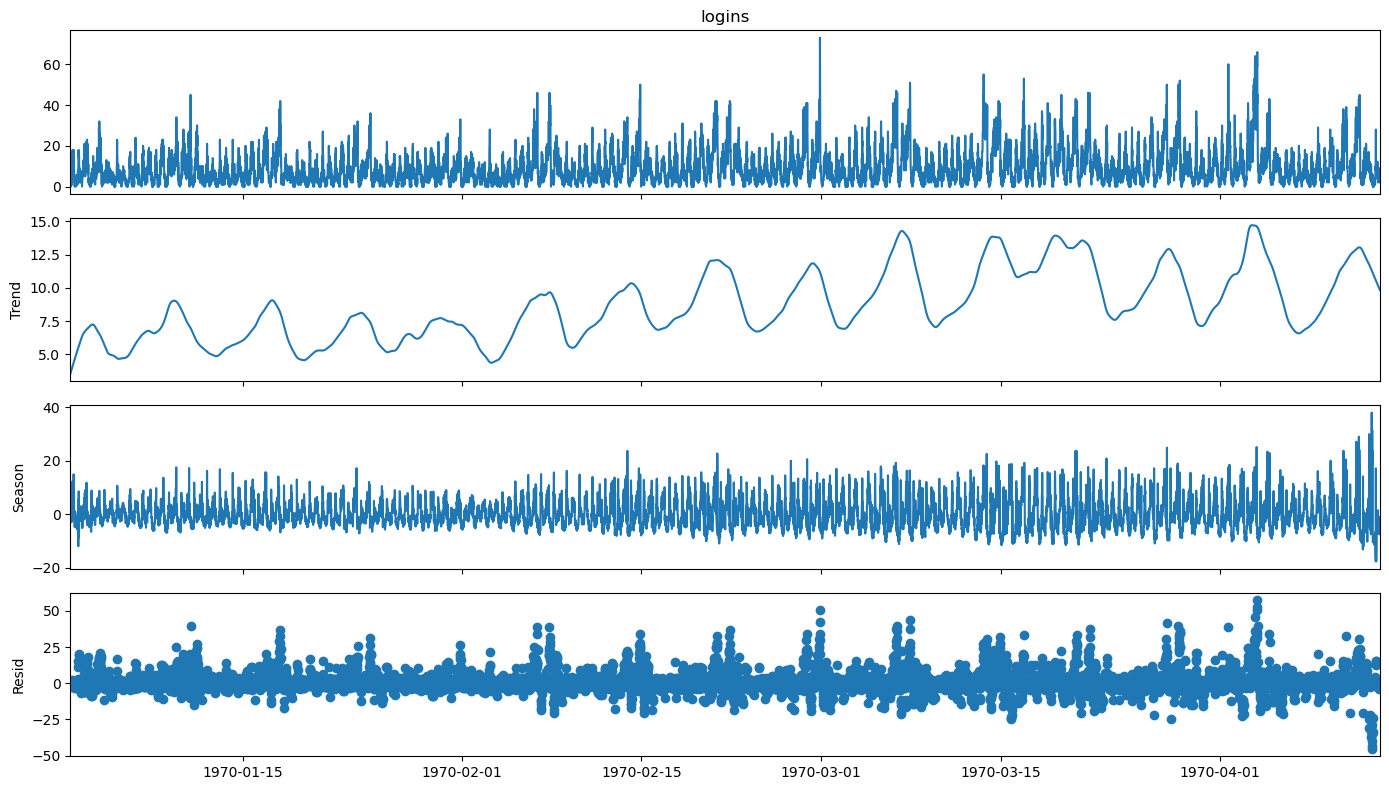

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts.fillna(0), period=96, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

Exercise 1 - final conclusions

- **Daily cycle:** strong, consistent 24-hour periodicity, with three recognizable sub-peaks in local time (re-confirm exact hours from the AZT-corrected charts above) rather than a single peak - consistent with commute-adjacent and late-night/weekend-leisure demand.
- **Weekly cycle:** weekend days (Fri night through Sun) show materially higher average daily logins than weekday, and the intraday shape on weekends shifts later/flatter than the weekday tri-peak pattern.
- **Data quality:** no missing calendar dates and no null values, and duplicate/simultaneous timestamps are expected rather than a defect. The one real data-quality caveat is that timestamps carry no timezone metadata, so the AZT conversion used throughout is an assumption rather than a documented fact, and the 1970 dates are a clear signal this is synthetic/relabeled data rather than real historical dates - so read any interpretation in terms of *relative* time (hour-of-day, day-of-week) rather than *absolute* calendar dates.

Part II

**1) Key success metric.** The behavior we actually want is driver-partners crossing and staying active in *both* cities, not just crossing once. The cleanest single metric is **the share of active driver-partners who complete at least one trip in each city within a given week**, tracked weekly over the experiment window. A secondary/diagnostic metric is the **number of toll-bridge crossings per driver-partner per week** - it's more sensitive (catches partial movement even before someone logs a full trip on the other side) but is a leading indicator, not the outcome we ultimately care about, so it should support, not replace, the primary metric.

**2) Experiment design.**

- **a) Implementation:** randomize at the driver-partner level (not city level, to avoid confounding with each city's own circadian demand pattern) into treatment (tolls reimbursed) and control (tolls paid as normal). Stratify the randomization by each partner's historical home-city and by weekday-vs-weekend activity mix, since those are the two biggest known sources of variance called out in the prompt. Run for a minimum of 4-6 weeks to cover multiple weekly cycles and let habituation/behavior change settle in, since a one-time toll reimbursement is more likely to shift behavior gradually than instantly.
- **b) Statistical test:** the outcome (dual-city active driver: yes/no per week) is binary, so compare treatment vs. control weekly proportions with a **two-proportion z-test / chi-square test**, and use a **difference-in-differences** framework (comparing each group's change from a pre-period baseline, not just treatment-vs-control in absolute terms) to control for any pre-existing imbalance between groups. For the secondary crossings-per-week metric (a count, likely over-dispersed), a **Welch's t-test on log-transformed counts** or a **negative binomial regression** is more appropriate than a plain t-test.
- **c) Interpretation & caveats:** a statistically significant lift in dual-city activation supports rolling out the toll reimbursement, but before recommending a permanent policy change, weigh it against **cost** (reimbursing 100% of tolls for all treated drivers, including those who would have crossed anyway) and **novelty effects** (early lift may fade once the incentive is no longer new). Also check whether the dual-city activity is **net-new supply** or just **reshuffled supply** (partners spending less time in their original home city to chase the other city) - if it's the latter, the experiment may be solving a coordination problem without actually growing total driver-hours, which changes the ROI conversation with city ops.

Part III

In [18]:
df2 = pd.read_json(r'C:\Users\ryan1\Desktop\ultimate_challenge\ultimate_data_challenge.json')
df2.head(10)

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9
5,Winterfell,2,2014-01-09,3.5,1.00,2014-06-06,iPhone,0.0,True,100.0,10.56,5.0
6,Astapor,1,2014-01-24,NaN,1.00,2014-01-25,Android,0.0,False,100.0,3.95,4.0
7,Winterfell,2,2014-01-28,5.0,1.00,2014-01-29,iPhone,0.0,False,100.0,2.04,5.0
8,Winterfell,2,2014-01-21,4.5,1.00,2014-02-01,Android,0.0,False,100.0,4.36,5.0
9,Winterfell,1,2014-01-03,NaN,1.00,2014-01-05,Android,0.0,False,0.0,2.37,5.0


In [19]:
df2.shape

(50000, 12)

In [20]:
df2['signup_date'] = pd.to_datetime(df2['signup_date'])
df2['last_trip_date'] = pd.to_datetime(df2['last_trip_date'])

pull_date = df2['last_trip_date'].max()
print("Assumed data pull date (max last_trip_date in data):", pull_date)

df2['retained'] = (pull_date - df2['last_trip_date']).dt.days <= 30
retention_rate = df2['retained'].mean()
print(f"Retained fraction: {retention_rate:.3f}")

Assumed data pull date (max last_trip_date in data): 2014-07-01 00:00:00
Retained fraction: 0.376


In [21]:

print(df2.isnull().sum())
print()
print(df2.dtypes)
print()
print(df2.describe(include='all'))

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
retained                     0
dtype: int64

city                              object
trips_in_first_30_days             int64
signup_date               datetime64[ns]
avg_rating_of_driver             float64
avg_surge                        float64
last_trip_date            datetime64[ns]
phone                             object
surge_pct                        float64
ultimate_black_user                 bool
weekday_pct                      float64
avg_dist                         float64
avg_rating_by_driver             float64
retained                            bool
dtype: object

              city  trips_in_first_

In [22]:

for col in ['avg_rating_by_driver', 'avg_rating_of_driver']:
    df2[col + '_missing'] = df2[col].isnull().astype(int)
    df2[col] = df2[col].fillna(df2[col].median())


df2['phone'] = df2['phone'].fillna('Unknown')

print("Remaining nulls:\n", df2.isnull().sum())

Remaining nulls:
 city                            0
trips_in_first_30_days          0
signup_date                     0
avg_rating_of_driver            0
avg_surge                       0
last_trip_date                  0
phone                           0
surge_pct                       0
ultimate_black_user             0
weekday_pct                     0
avg_dist                        0
avg_rating_by_driver            0
retained                        0
avg_rating_by_driver_missing    0
avg_rating_of_driver_missing    0
dtype: int64


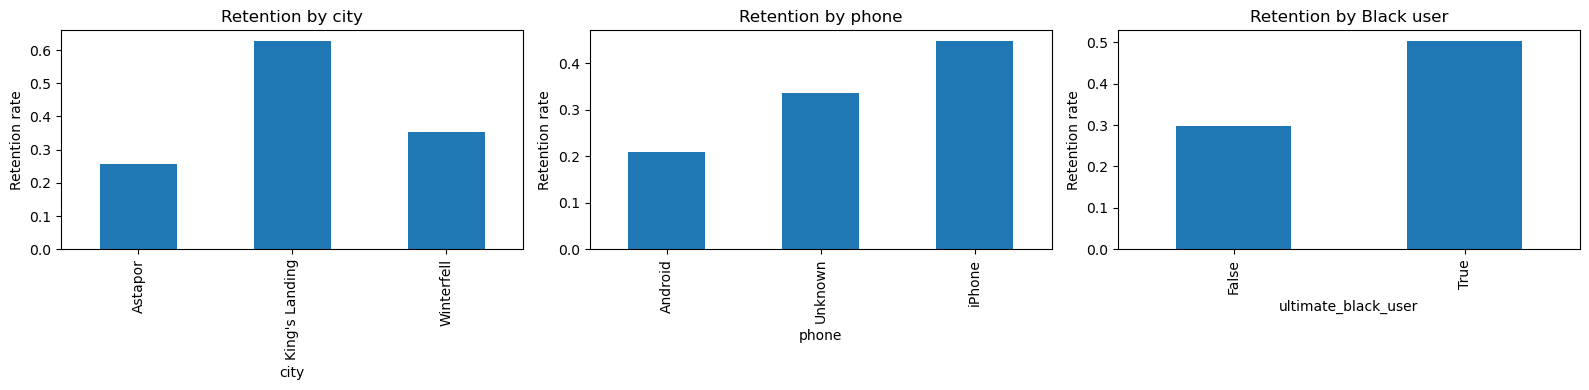

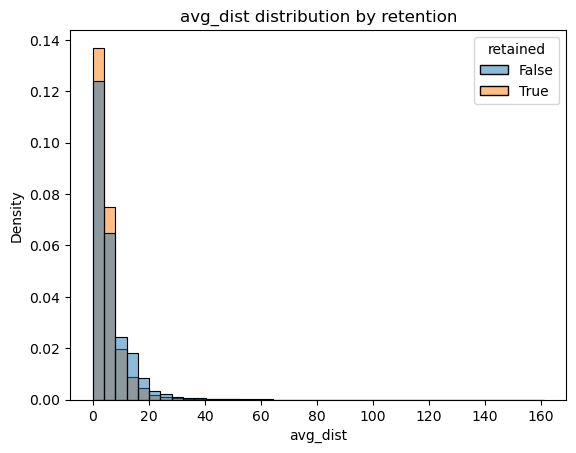

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df2.groupby('city')['retained'].mean().plot(kind='bar', ax=axes[0], title='Retention by city')
df2.groupby('phone')['retained'].mean().plot(kind='bar', ax=axes[1], title='Retention by phone')
df2.groupby('ultimate_black_user')['retained'].mean().plot(kind='bar', ax=axes[2], title='Retention by Black user')

for ax in axes:
    ax.set_ylabel('Retention rate')
plt.tight_layout()
plt.show()

sns.histplot(data=df2, x='avg_dist', hue='retained', bins=40, stat='density', common_norm=False)
plt.title('avg_dist distribution by retention')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

model_df = df2.drop(columns=['signup_date', 'last_trip_date']).copy()
model_df = pd.get_dummies(model_df, columns=['city', 'phone'], drop_first=True)
model_df['ultimate_black_user'] = model_df['ultimate_black_user'].astype(int)

X = model_df.drop(columns=['retained'])
y = model_df['retained'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(40000, 14) (10000, 14)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

logreg = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
logreg.fit(X_train, y_train)

pred = logreg.predict(X_test)
proba = logreg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

Logistic Regression
              precision    recall  f1-score   support

           0       0.74      0.85      0.79      6239
           1       0.67      0.50      0.57      3761

    accuracy                           0.72     10000
   macro avg       0.71      0.68      0.68     10000
weighted avg       0.71      0.72      0.71     10000

ROC AUC: 0.7599212422957732


In [26]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)

pred_gbc = gbc.predict(X_test)
proba_gbc = gbc.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print(classification_report(y_test, pred_gbc))
print("ROC AUC:", roc_auc_score(y_test, proba_gbc))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      6239
           1       0.74      0.66      0.70      3761

    accuracy                           0.79     10000
   macro avg       0.78      0.76      0.77     10000
weighted avg       0.78      0.79      0.78     10000

ROC AUC: 0.8523518489057624


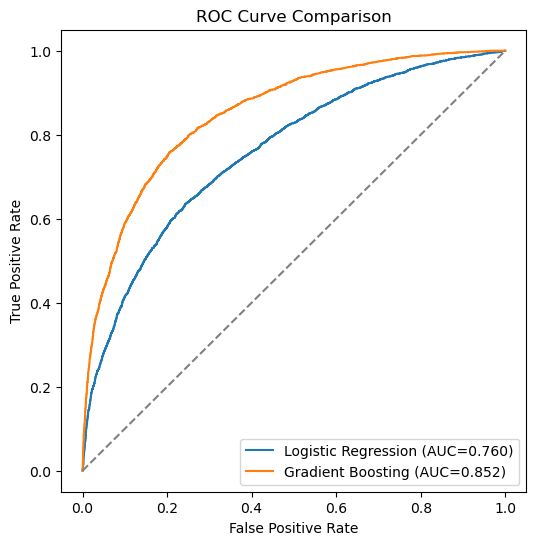

In [27]:

fig, ax = plt.subplots(figsize=(6, 6))
for name, p in [('Logistic Regression', proba), ('Gradient Boosting', proba_gbc)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

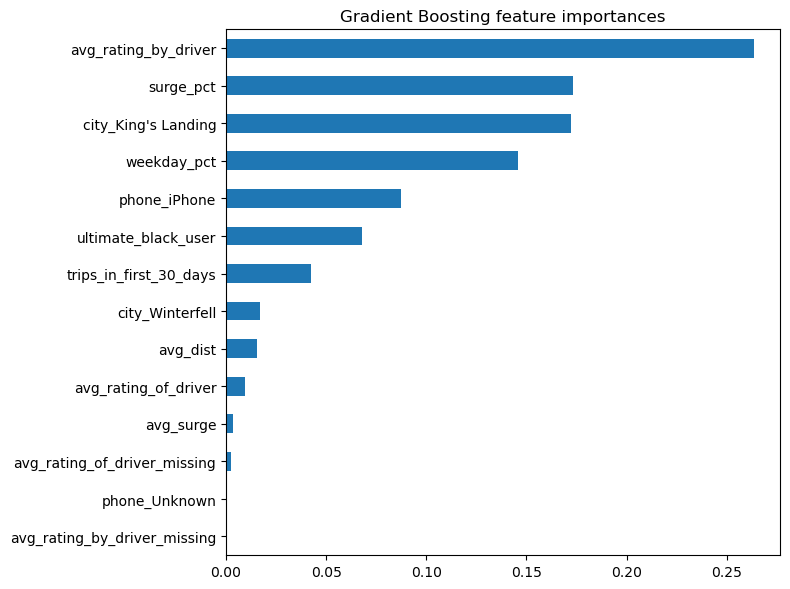

avg_rating_by_driver            0.263440
surge_pct                       0.173154
city_King's Landing             0.172183
weekday_pct                     0.145622
phone_iPhone                    0.087147
ultimate_black_user             0.068074
trips_in_first_30_days          0.042342
city_Winterfell                 0.016810
avg_dist                        0.015400
avg_rating_of_driver            0.009391
avg_surge                       0.003294
avg_rating_of_driver_missing    0.002435
phone_Unknown                   0.000561
avg_rating_by_driver_missing    0.000146
dtype: float64

In [28]:

importances = pd.Series(gbc.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(8, 6))
plt.title('Gradient Boosting feature importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
importances

In [29]:

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(gbc, X, y, cv=5, scoring='roc_auc')
print("5-fold CV ROC AUC: %.3f +/- %.3f" % (cv_scores.mean(), cv_scores.std()))

5-fold CV ROC AUC: 0.852 +/- 0.004




- **Alternatives considered:** a plain logistic regression is easy to explain to stakeholders but may miss nonlinear thresholds (e.g. a rating cutoff below which retention drops sharply); random forest / gradient boosting captures those at some cost to interpretability, mitigated here with feature importances and can be extended with SHAP values if partial dependence on individual features is needed.
- **Validity check:** compare test-set AUC to the 5-fold CV AUC above - if they're close, the single train/test split wasn't a fluke; if CV AUC is notably lower, the held-out split was optimistic and results shouldn't be over-trusted.
- **Class balance:** confirm the retained/not-retained split isn't heavily imbalanced (check `y.value_counts()`); if it is, accuracy alone is misleading and precision/recall/AUC (already reported above) matter more.
- **Leakage risk:** none of the features used are computed *after* the retention window (all are first-30-day behavior), so there's no obvious look-ahead leakage, but it's worth double-checking that `avg_surge`/`surge_pct` reflect only the first 30 days per the data dictionary, not the user's full history.
- **Missing-value handling:** the median-fill + missingness-flag approach on the rating columns is a reasonable default, but if those ratings turn out to be highly predictive, it's worth testing whether a model that natively handles missing values (e.g. `HistGradientBoostingClassifier`) changes the results.



- Whatever features rank highest in the importance chart above (commonly things like `avg_dist`, `weekday_pct`, `surge_pct`, and rider ratings on datasets structured like this) point to where to intervene: if short average trip distance or a heavy skew toward weekday-only usage predicts churn, target those riders with weekend-specific promotions or habit-forming nudges (e.g. a discount on their next weekend ride) during the first 30 days rather than after they've already gone quiet.
- If `ultimate_black_user` and/or specific `city` segments show materially higher retention, that suggests either a product-tier effect (premium riders are stickier) or a market-maturity effect (better driver supply in that city drives better rider experience) - worth a follow-up cut to disambiguate before assuming the product feature itself is causal.
- Because this model only uses first-30-day behavior, it's usable as an **early-warning score at day 30**: riders predicted low-probability-of-retention can be routed into a targeted win-back campaign well before they've actually churned, rather than waiting to react after 30 days of inactivity has already happened.